# Loading the Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
data = "/content/drive/MyDrive/IAPC Project/Spectrogram Dataset/spectrogram_dataset_encoded.csv"
df = pd.read_csv(data)

# Dataset Uploadation

In [3]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

In [4]:
df = df[["file_path", "label_encoded", "language_encoded"]]

print(df.head())

                                           file_path  label_encoded  \
0  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
1  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
2  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
3  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
4  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   

   language_encoded  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  


In [5]:
df_eng = df[df["language_encoded"] == 0].reset_index(drop=True)

df_hin = df[df["language_encoded"] == 1].reset_index(drop=True)

print("English samples:", len(df_eng))
print("Hindi samples:", len(df_hin))

English samples: 706
Hindi samples: 992


In [6]:
class SpectrogramDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "file_path"]
        label = self.df.loc[idx, "label_encoded"]

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [8]:
dataset_eng = SpectrogramDataset(df_eng, transform=transform)

dataset_hin = SpectrogramDataset(df_hin, transform=transform)

In [9]:
from sklearn.model_selection import train_test_split

train_eng, remaining_eng = train_test_split(df_eng, test_size=0.3, random_state=42)
train_hin, remaining_hin = train_test_split(df_hin, test_size=0.3, random_state=42)
val_eng, test_eng = train_test_split(remaining_eng, test_size=0.5, random_state=42)
val_hin, test_hin = train_test_split(remaining_hin, test_size=0.5, random_state=42)

train_eng = train_eng.reset_index(drop=True)
val_eng   = val_eng.reset_index(drop=True)
test_eng  = test_eng.reset_index(drop=True)

train_hin = train_hin.reset_index(drop=True)
val_hin   = val_hin.reset_index(drop=True)
test_hin  = test_hin.reset_index(drop=True)

train_dataset_eng = SpectrogramDataset(train_eng, transform)
val_dataset_eng   = SpectrogramDataset(val_eng, transform)
test_dataset_eng  = SpectrogramDataset(test_eng, transform)

train_dataset_hin = SpectrogramDataset(train_hin, transform)
val_dataset_hin   = SpectrogramDataset(val_hin, transform)
test_dataset_hin  = SpectrogramDataset(test_hin, transform)

In [10]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader_eng = DataLoader(train_dataset_eng, batch_size=batch_size, shuffle=True)
val_loader_eng   = DataLoader(val_dataset_eng, batch_size=batch_size, shuffle=False)
test_loader_eng  = DataLoader(test_dataset_eng, batch_size=batch_size, shuffle=False)

train_loader_hin = DataLoader(train_dataset_hin, batch_size=batch_size, shuffle=True)
val_loader_hin   = DataLoader(val_dataset_hin, batch_size=batch_size, shuffle=False)
test_loader_hin  = DataLoader(test_dataset_hin, batch_size=batch_size, shuffle=False)

# Training

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VoiceCNN(nn.Module):
    def __init__(self):
        super(VoiceCNN, self).__init__()

        # 🔹 Convolutional Layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        # 🔹 Fully Connected Layers
        self.fc1 = nn.Linear(256 * 8 * 8, 256)   # adjust if image size changes
        self.dropout = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)

        self.fc3 = nn.Linear(128, 1)    # Output layer

    def forward(self, x, return_features=False):

        # 🔹 Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # 🔹 Conv Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # 🔹 Conv Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # 🔹 Conv Block 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # 🔹 Flatten
        x = x.view(x.size(0), -1)

        # 🔹 Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        features = F.relu(self.fc2(x))

        output = torch.sigmoid(self.fc3(features))

        if return_features:
            return features

        return output

## English Model

### English Model Training

In [12]:
model_eng = VoiceCNN()

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model_eng.parameters(), lr=0.0001)

In [13]:
num_epochs = 10

for epoch in range(num_epochs):
    model_eng.train()

    running_loss = 0.0

    for images, labels in train_loader_eng:

        # Forward pass
        outputs = model_eng(images).squeeze()

        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 7.4977
Epoch [2/10], Loss: 4.5415
Epoch [3/10], Loss: 2.2584
Epoch [4/10], Loss: 1.1403
Epoch [5/10], Loss: 0.5359
Epoch [6/10], Loss: 0.4096
Epoch [7/10], Loss: 0.3227
Epoch [8/10], Loss: 0.2693
Epoch [9/10], Loss: 0.1254
Epoch [10/10], Loss: 0.0877


### Accuracy

In [14]:
import torch

def evaluate_model(model, dataloader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images).squeeze()
            preds = (outputs > 0.5).float()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

### Accuracy of all Splits

In [15]:
train_acc = evaluate_model(model_eng, train_loader_eng)
val_acc   = evaluate_model(model_eng, val_loader_eng)
test_acc  = evaluate_model(model_eng, test_loader_eng)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 1.0000
Validation Accuracy: 1.0000
Test Accuracy: 1.0000


### Comparison Graph

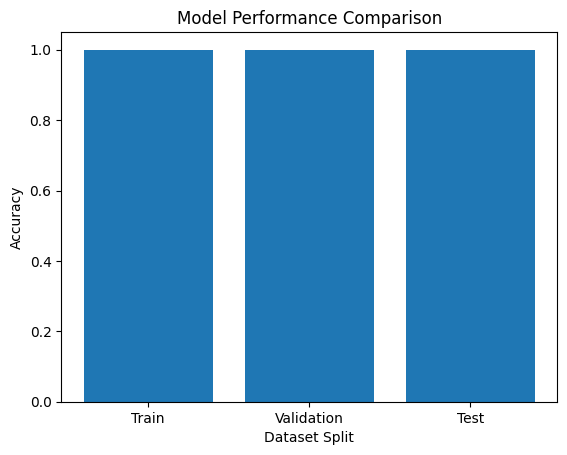

In [16]:
import matplotlib.pyplot as plt

splits = ['Train', 'Validation', 'Test']
accuracies = [train_acc, val_acc, test_acc]

plt.figure()
plt.bar(splits, accuracies)

plt.xlabel("Dataset Split")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")

plt.show()

## Hindi Model

### Hindi Model Training

In [17]:
model_hin = VoiceCNN()

In [18]:
num_epochs = 10

for epoch in range(num_epochs):
    model_hin.train()

    running_loss = 0.0

    for images, labels in train_loader_hin:

        # Forward pass
        outputs = model_hin(images).squeeze()

        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"[Hindi] Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

[Hindi] Epoch [1/10], Loss: 15.1571
[Hindi] Epoch [2/10], Loss: 15.1698
[Hindi] Epoch [3/10], Loss: 15.2140
[Hindi] Epoch [4/10], Loss: 15.2000
[Hindi] Epoch [5/10], Loss: 15.1522
[Hindi] Epoch [6/10], Loss: 15.1686
[Hindi] Epoch [7/10], Loss: 15.1473
[Hindi] Epoch [8/10], Loss: 15.1839
[Hindi] Epoch [9/10], Loss: 15.1705
[Hindi] Epoch [10/10], Loss: 15.2292


### Accuracy of all Splits

In [19]:
train_acc_hin = evaluate_model(model_hin, train_loader_hin)
val_acc_hin   = evaluate_model(model_hin, val_loader_hin)
test_acc_hin  = evaluate_model(model_hin, test_loader_hin)

print(f"Hindi Train Accuracy: {train_acc_hin:.4f}")
print(f"Hindi Validation Accuracy: {val_acc_hin:.4f}")
print(f"Hindi Test Accuracy: {test_acc_hin:.4f}")

Hindi Train Accuracy: 0.6124
Hindi Validation Accuracy: 0.6846
Hindi Test Accuracy: 0.6107


### Comparison Graphs

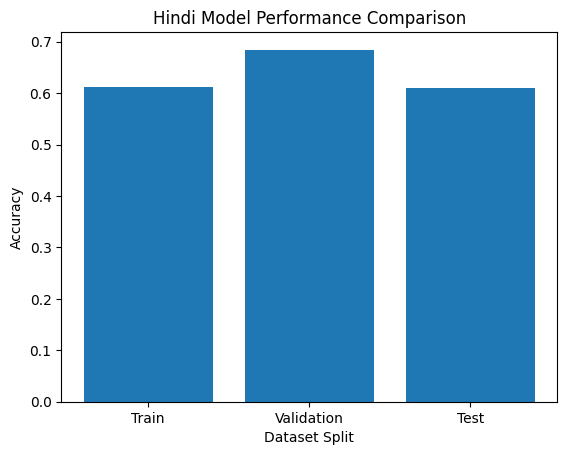

In [20]:
import matplotlib.pyplot as plt

splits = ['Train', 'Validation', 'Test']
accuracies_hin = [train_acc_hin, val_acc_hin, test_acc_hin]

plt.figure()
plt.bar(splits, accuracies_hin)

plt.xlabel("Dataset Split")
plt.ylabel("Accuracy")
plt.title("Hindi Model Performance Comparison")

plt.show()

# Similarity Check

In [21]:
def extract_features(model, dataloader):
    features_list = []
    labels_list = []

    model.eval()

    with torch.no_grad():
        for images, labels in dataloader:

            outputs = model(images, return_features=True)

            features_list.append(outputs.detach().cpu())
            labels_list.append(labels.detach().cpu())

    features = torch.cat(features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)

    return features, labels

## Conversion to Numerical Representations

In [22]:
features_eng, labels_eng = extract_features(model_eng, test_loader_eng)
features_hin, labels_hin = extract_features(model_hin, test_loader_hin)

## Conversion to NumPy Arrays

In [23]:
features_eng = features_eng.cpu().numpy()
labels_eng = labels_eng.cpu().numpy()

features_hin = features_hin.cpu().numpy()
labels_hin = labels_hin.cpu().numpy()

## labels to separate them into two groups

In [24]:
ai_eng = features_eng[labels_eng == 0]
human_eng = features_eng[labels_eng == 1]

ai_hin = features_hin[labels_hin == 0]
human_hin = features_hin[labels_hin == 1]

## Cosine Similarity Code

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [26]:
sim_eng = cosine_similarity(ai_eng, human_eng)
sim_hin = cosine_similarity(ai_hin, human_hin)

print("English AI-Human similarity:", np.mean(sim_eng))
print("Hindi AI-Human similarity:", np.mean(sim_hin))

English AI-Human similarity: 0.4155183
Hindi AI-Human similarity: 0.7173084


In [27]:
sim_human_eng = cosine_similarity(human_eng, human_eng)
sim_ai_eng = cosine_similarity(ai_eng, ai_eng)

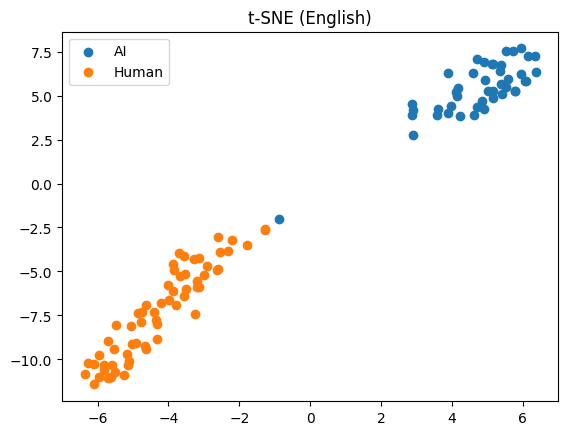

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(features_eng)

plt.scatter(reduced[labels_eng==0,0], reduced[labels_eng==0,1], label="AI")
plt.scatter(reduced[labels_eng==1,0], reduced[labels_eng==1,1], label="Human")
plt.legend()
plt.title("t-SNE (English)")
plt.show()

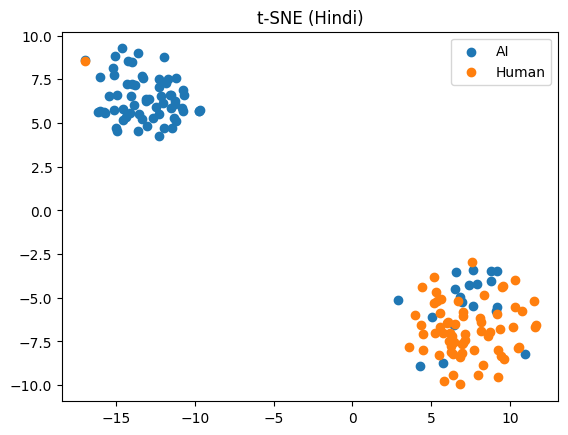

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(features_hin)

plt.scatter(reduced[labels_hin==0,0], reduced[labels_hin==0,1], label="AI")
plt.scatter(reduced[labels_hin==1,0], reduced[labels_hin==1,1], label="Human")
plt.legend()
plt.title("t-SNE (Hindi)")
plt.show()

In [31]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def paired_similarity(A, B):
    n = min(len(A), len(B))
    sims = []
    for i in range(n):
        sims.append(
            cosine_similarity(A[i].reshape(1,-1),
                              B[i].reshape(1,-1))[0,0]
        )
    return np.array(sims)

def within_similarity(X, k=200):
    # sample k pairs to avoid O(N^2)
    idx = np.random.choice(len(X), size=min(k, len(X)), replace=False)
    sims = []
    for i in idx:
        j = np.random.randint(0, len(X))
        sims.append(cosine_similarity(X[i].reshape(1,-1),
                                      X[j].reshape(1,-1))[0,0])
    return np.array(sims)

# English
sim_e_ah = paired_similarity(ai_eng, human_eng)
sim_e_aa = within_similarity(ai_eng)
sim_e_hh = within_similarity(human_eng)

# Hindi
sim_h_ah = paired_similarity(ai_hin, human_hin)
sim_h_aa = within_similarity(ai_hin)
sim_h_hh = within_similarity(human_hin)

print("English:", sim_e_ah.mean(), sim_e_aa.mean(), sim_e_hh.mean())
print("Hindi:",   sim_h_ah.mean(), sim_h_aa.mean(), sim_h_hh.mean())

English: 0.4248558 0.9927071 0.96153826
Hindi: 0.71478915 0.79646045 0.82439685


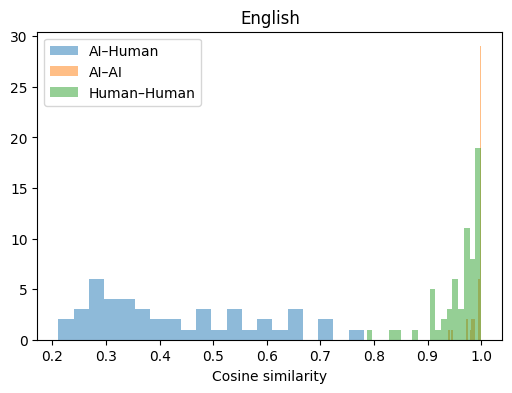

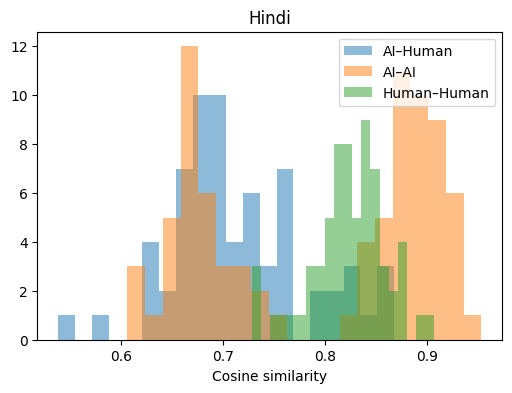

In [32]:
import matplotlib.pyplot as plt

def plot_hist(title, ah, aa, hh):
    plt.figure(figsize=(6,4))
    plt.hist(ah, bins=20, alpha=0.5, label="AI–Human")
    plt.hist(aa, bins=20, alpha=0.5, label="AI–AI")
    plt.hist(hh, bins=20, alpha=0.5, label="Human–Human")
    plt.legend(); plt.title(title); plt.xlabel("Cosine similarity"); plt.show()

plot_hist("English", sim_e_ah, sim_e_aa, sim_e_hh)
plot_hist("Hindi",   sim_h_ah, sim_h_aa, sim_h_hh)